In [ ]:
!pip install fastparquet

In [208]:
import pandas as pd

notes = pd.read_parquet("data/sample_user_note_traj.parquet")
ratings = pd.read_parquet("data/sample_user_rating_traj.parquet")
requests = pd.read_parquet("data/sample_user_request_traj.parquet")

In [209]:
notes    = notes.rename(columns={'noteAuthorParticipantId':'userId'})
ratings  = ratings.rename(columns={'raterParticipantId':'userId'})
requests = requests.rename(columns={'requesterParticipantId':'userId'})

df = (notes
      .merge(ratings,  on=['userId','userMonth','calendarMonth'], how='outer')
      .merge(requests, on=['userId','userMonth','calendarMonth'], how='outer')
      .fillna(0))

for col in ['notesCreated','notesRated','requestsMade']:
    df[col] = df[col].astype(int)

In [210]:
# Assuming NaN means the user had no activity recorded in that category for the given month,
# so we treat missing values as 0 (i.e., no notes written, no ratings made, or no requests submitted).
df[["notesCreated", "notesRated", "requestsMade"]] = (
    df[["notesCreated", "notesRated", "requestsMade"]]
    .fillna(0)
)

In [211]:
import numpy as np

def classify_user(row):
    notes = row["notesCreated"]
    ratings = row["notesRated"]
    requests = row["requestsMade"]

    # 1. Writers 
    if notes > 0:
        if notes == 1:
            return "single-note writer"
        elif 2 <= notes <= 9:
            return "single-digit writer"
        else:
            return "double-digit writer"

    # 2. Raters (wrote 0 notes, and ...)
    if notes == 0 and ratings > 0:
        if ratings == 1:
            return "single-note rater"
        elif 2 <= ratings <= 9:
            return "single-digit rater"
        else:
            return "double-digit rater"

    # 3. Requestors (wrote and rated 0 notes, and ...)
    if notes == 0 and ratings == 0 and requests > 0:
        if requests == 1:
            return "single-post requestor"
        elif 2 <= requests <= 9:
            return "single-digit requestor"
        else:
            return "double-digit requestor"

    # 4. Otherwise
    return "not active"


df["user_class"] = df.apply(classify_user, axis=1)
df['user_class'].value_counts()

user_class
single-digit rater        29655
single-note rater         21890
single-post requestor     17126
double-digit rater        13646
single-digit requestor     5358
single-note writer         2648
single-digit writer        1459
double-digit requestor      415
double-digit writer          84
Name: count, dtype: int64

#### Transition Probability 

In [212]:
df['calendarMonth'] = pd.to_datetime(df['calendarMonth'] + '-01')

In [232]:
user_ranges = df.groupby('userId')['calendarMonth'].agg(['min','max']).reset_index()

rows = []
for _, row in user_ranges.iterrows():
    for month in pd.date_range(row['min'], row['max'], freq='MS'):
        rows.append((row['userId'], month))

expanded = pd.DataFrame(rows, columns=['userId','calendarMonth'])

df_full = expanded.merge(df[['userId','calendarMonth','user_class']], on=['userId','calendarMonth'], how='left')
df_full['user_class'] = df_full['user_class'].fillna('not active')

In [233]:
df_full = df_full.sort_values(['userId','calendarMonth']).reset_index(drop=True)
df_full['next_class'] = df_full.groupby('userId')['user_class'].shift(-1)
transitions = df_full.dropna(subset=['next_class'])
counts = pd.crosstab(transitions['user_class'], transitions['next_class'])
probs = counts.div(counts.sum(axis=1), axis=0)
probs

next_class,double-digit rater,double-digit requestor,double-digit writer,not active,single-digit rater,single-digit requestor,single-digit writer,single-note rater,single-note writer,single-post requestor
user_class,,,,,,,,,,
double-digit rater,0.554065,0.000000,0.000758,0.032356,0.279457,0.000152,0.031068,0.033038,0.069031,0.000076
double-digit requestor,0.002577,0.448454,0.000000,0.041237,0.007732,0.399485,0.000000,0.005155,0.000000,0.095361
double-digit writer,0.097561,0.000000,0.365854,0.036585,0.097561,0.000000,0.317073,0.012195,0.073171,0.000000
not active,0.015717,0.000320,0.000046,0.692816,0.100988,0.013082,0.001005,0.132940,0.003518,0.039567
single-digit rater,0.113200,0.000183,0.000439,0.234556,0.449106,0.001097,0.007717,0.169745,0.021689,0.002268
single-digit requestor,0.003942,0.038205,0.000000,0.277138,0.014251,0.373863,0.000910,0.008187,0.000606,0.282899
single-digit writer,0.267466,0.000000,0.015526,0.034580,0.145378,0.000000,0.283698,0.040932,0.212421,0.000000
single-note rater,0.035514,0.000158,0.000105,0.509535,0.233517,0.002679,0.002732,0.202627,0.008353,0.004781
single-note writer,0.319604,0.000000,0.001980,0.080000,0.267327,0.000396,0.105743,0.064158,0.160396,0.000396


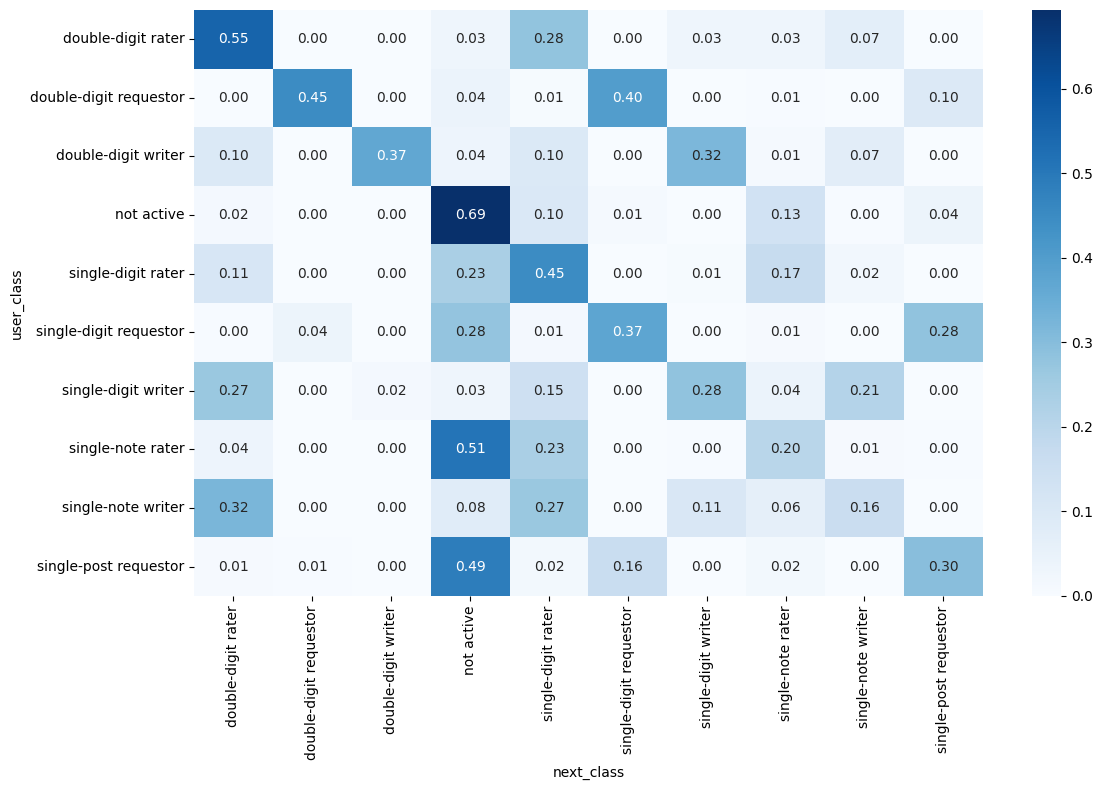

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(probs, annot=True, fmt='.2f', cmap='Blues', ax=ax)
plt.tight_layout()
plt.show()

#### Calendar Month

In [240]:
MAX_MONTHS = 12  

flows_cal = (
    transitions
    .sort_values('calendarMonth')
    .groupby(['calendarMonth', 'user_class', 'next_class'])
    .size()
    .reset_index(name='value')
)

flows_cal['month_str'] = pd.to_datetime(flows_cal['calendarMonth']).dt.strftime('%Y-%m')

flows_cal['source'] = flows_cal['month_str'] + "_" + flows_cal['user_class']

flows_cal['target'] = (
    pd.to_datetime(flows_cal['calendarMonth']) + pd.DateOffset(months=1)
).dt.strftime('%Y-%m') + "_" + flows_cal['next_class']

In [241]:
nodes_cal = pd.Index(flows_cal['source'].tolist() + flows_cal['target'].tolist()).unique()
node_map_cal = {name: i for i, name in enumerate(nodes_cal)}

flows_cal['source_id'] = flows_cal['source'].map(node_map_cal)
flows_cal['target_id'] = flows_cal['target'].map(node_map_cal)

# flows_cal = flows_cal[flows_cal['value'] > 50]

In [243]:
def shorten(label):
    month, cls = label.split("_", 1)

    mapping = {
        "single-note writer": "SN_W",
        "single-digit writer": "SD_W",
        "double-digit writer": "DD_W",
        "single-note rater": "SN_R",
        "single-digit rater": "SD_R",
        "double-digit rater": "DD_R",
        "single-post requestor": "SP_Q",
        "single-digit requestor": "SD_Q",
        "double-digit requestor": "DD_Q",
        "not active": "NA"
    }

    return f"{mapping[cls]} ({month})"

labels = [shorten(n) for n in nodes_cal]

def get_class(label):
    return label.split("_", 1)[1]

color_map = {
    "single-note writer": "rgb(183, 230, 236)",
    "single-digit writer": "rgb(101, 202, 222)",
    "double-digit writer": "rgb(37, 150, 190)",

    "single-note rater": "rgb(252, 221, 157)",
    "single-digit rater": "rgb(242, 189, 151)",
    "double-digit rater": "rgb(233, 145, 81)",

    "single-post requestor": "rgb(144, 232, 168)",
    "single-digit requestor": "rgb(70, 212, 107)",
    "double-digit requestor": "rgb(0, 156, 41)",

    "not active": "lightgray"
}

node_colors = [color_map[get_class(n)] for n in nodes_cal]
link_colors = [node_colors[src] for src in flows_cal['source_id']]


In [244]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=10,
        thickness=10,
        line=dict(
            color=node_colors,   # border matches fill
            width=1
        ),
        color=node_colors
    ),
    link=dict(
        source=flows_cal['source_id'],
        target=flows_cal['target_id'],
        value=flows_cal['value'],
        color=link_colors
    )
)])

fig.update_layout(
    width=1500,   # try 2000–4000
    height=1000
)

fig.show()

#### Transition User Month

In [225]:
user_ranges = df.groupby('userId')['userMonth'].agg(['min','max']).reset_index()

rows = []
for _, row in user_ranges.iterrows():
    for m in range(int(row['min']), int(row['max']) + 1):
        rows.append((row['userId'], m))

expanded = pd.DataFrame(rows, columns=['userId','userMonth'])

In [226]:
df_full = expanded.merge(
    df[['userId','userMonth','user_class']],
    on=['userId','userMonth'],
    how='left'
)

df_full['user_class'] = df_full['user_class'].fillna('not active')

df_full = df_full.sort_values(['userId','userMonth']).reset_index(drop=True)

df_full['next_class'] = df_full.groupby('userId')['user_class'].shift(-1)

transitions = df_full.dropna(subset=['next_class'])

In [227]:
MAX_MONTH = 12

flows = (
    transitions[transitions['userMonth'] < MAX_MONTH]
    .groupby(['userMonth', 'user_class', 'next_class'])
    .size()
    .reset_index(name='value')
)

flows['source'] = flows['userMonth'].astype(str) + "_" + flows['user_class']
flows['target'] = (flows['userMonth'] + 1).astype(str) + "_" + flows['next_class']

nodes = pd.Index(flows['source'].tolist() + flows['target'].tolist()).unique()

node_map = {name: i for i, name in enumerate(nodes)}
flows['source_id'] = flows['source'].map(node_map)
flows['target_id'] = flows['target'].map(node_map)
# flows = flows[flows['value'] > 50]


In [ ]:
def shorten(label):
    month, cls = label.split("_", 1)

    mapping = {
        "single-note writer": "SN_W",
        "single-digit writer": "SD_W",
        "double-digit writer": "DD_W",
        "single-note rater": "SN_R",
        "single-digit rater": "SD_R",
        "double-digit rater": "DD_R",
        "single-post requestor": "SP_Q",
        "single-digit requestor": "SD_Q",
        "double-digit requestor": "DD_Q",
        "not active": "NA"
    }

    return f"{mapping[cls]} (t{month})"

labels = [shorten(n) for n in nodes]



In [204]:
def get_class(label):
    return label.split("_", 1)[1]

color_map = {
    "single-note writer": "rgb(183, 230, 236)",
    "single-digit writer": "rgb(101, 202, 222)",
    "double-digit writer": "rgb(37, 150, 190)",

    "single-note rater": "rgb(252, 221, 157)",
    "single-digit rater": "rgb(242, 189, 151)",
    "double-digit rater": "rgb(233, 145, 81)",

    "single-post requestor": "rgb(144, 232, 168)",
    "single-digit requestor": "rgb(70, 212, 107)",
    "double-digit requestor": "rgb(0, 156, 41)",

    "not active": "lightgray"
}

node_colors = [color_map[get_class(n)] for n in nodes]
link_colors = [node_colors[src] for src in flows['source_id']]

In [205]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=10,
        thickness=10,
        line=dict(
            color=node_colors,   # border matches fill
            width=1
        ),
        color=node_colors
    ),
    link=dict(
        source=flows['source_id'],
        target=flows['target_id'],
        value=flows['value'],
        color=link_colors
    )
)])

fig.update_layout(
    width=1500,   # try 2000–4000
    height=400
)

fig.show()

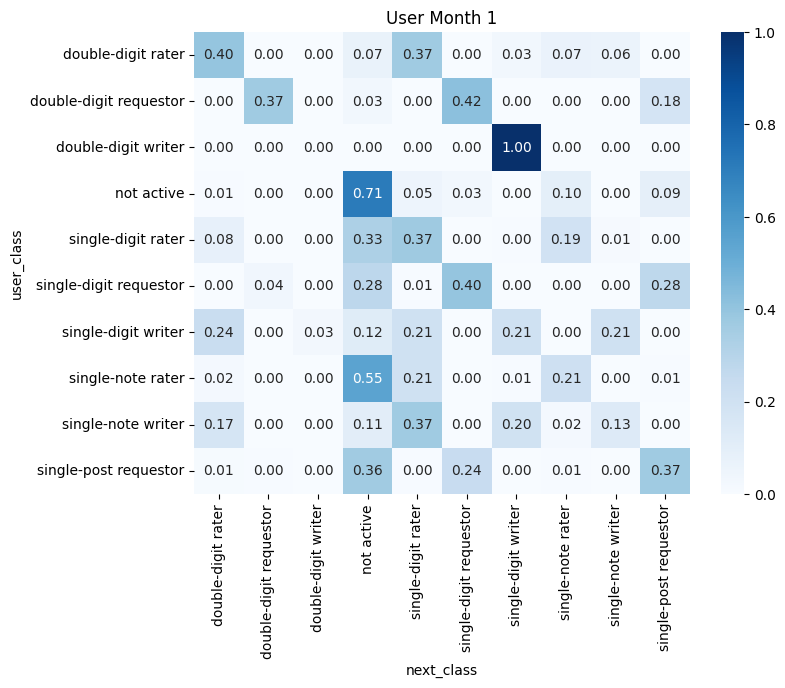

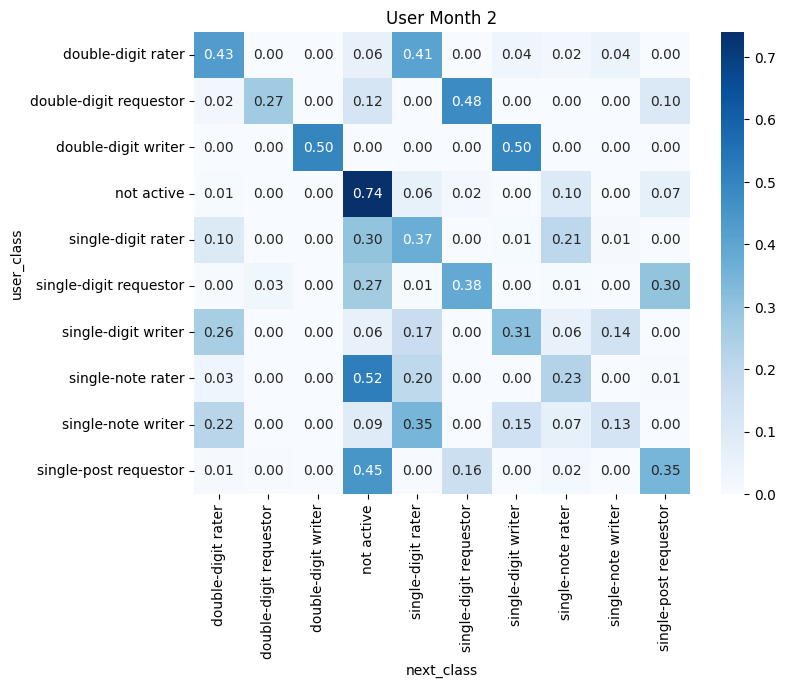

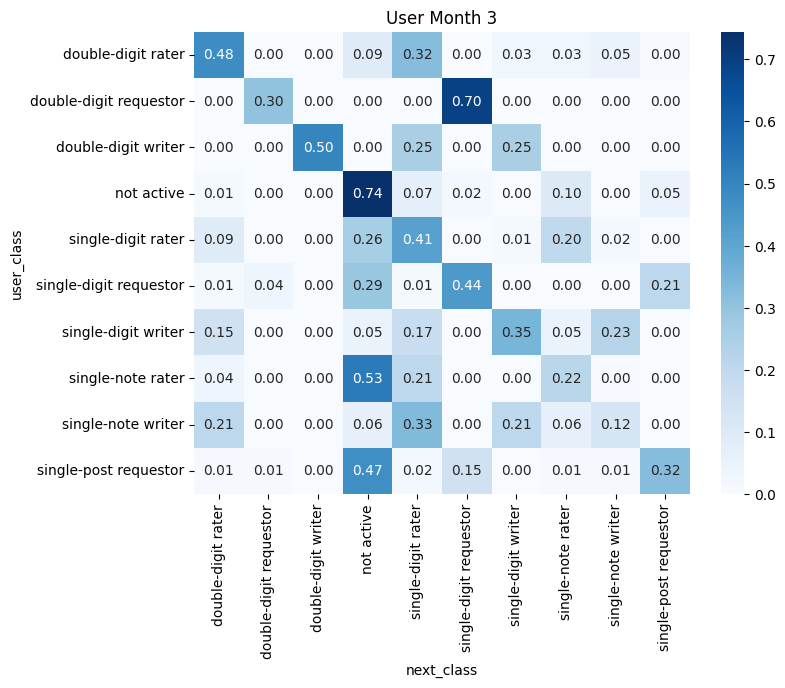

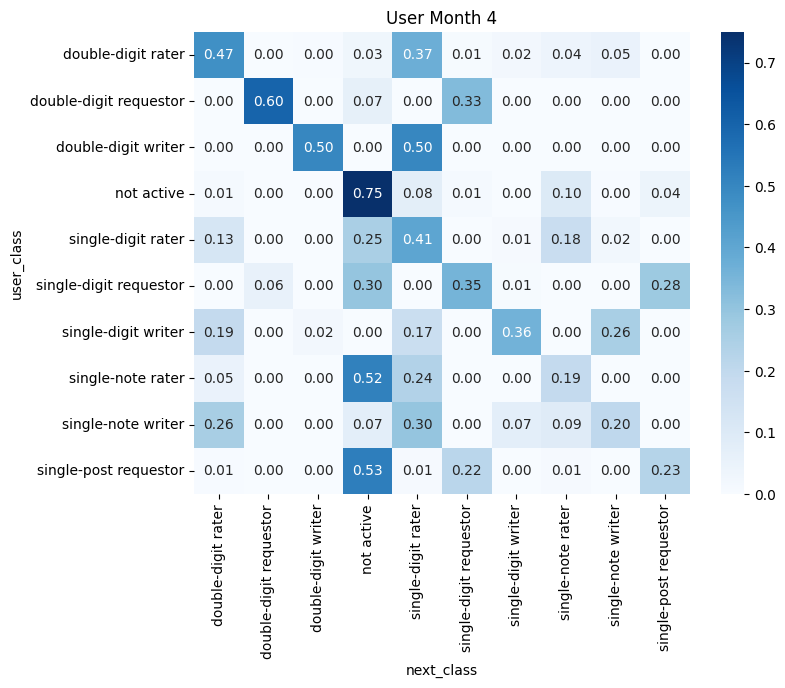

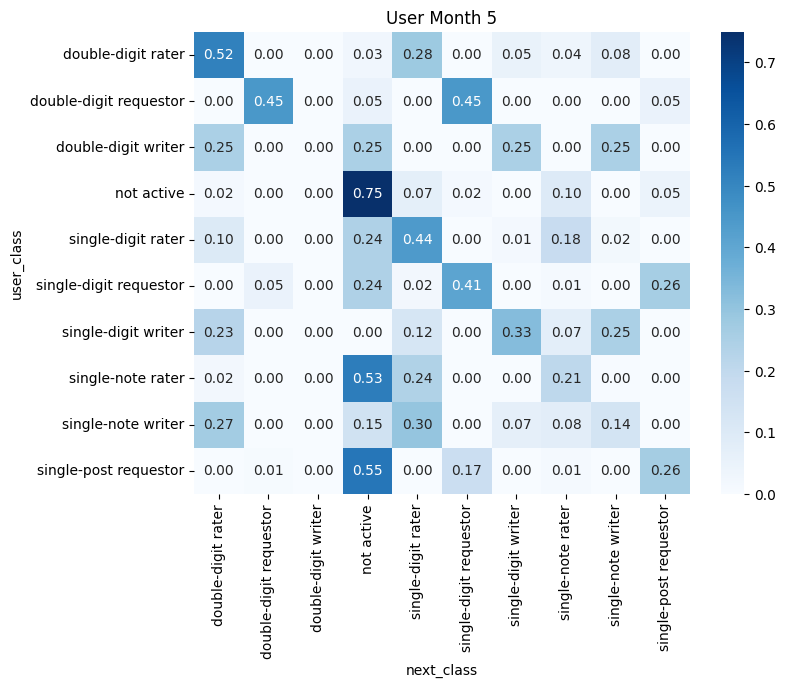

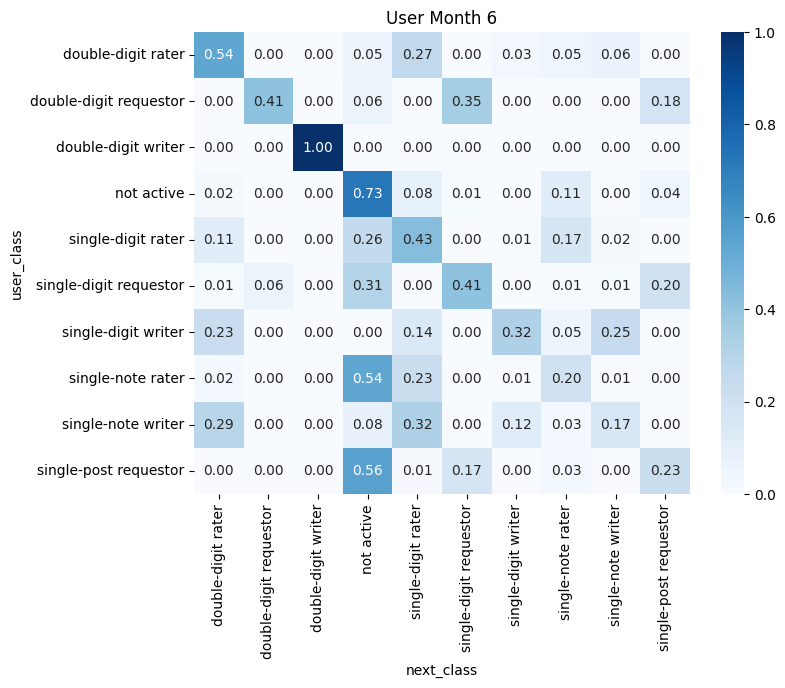

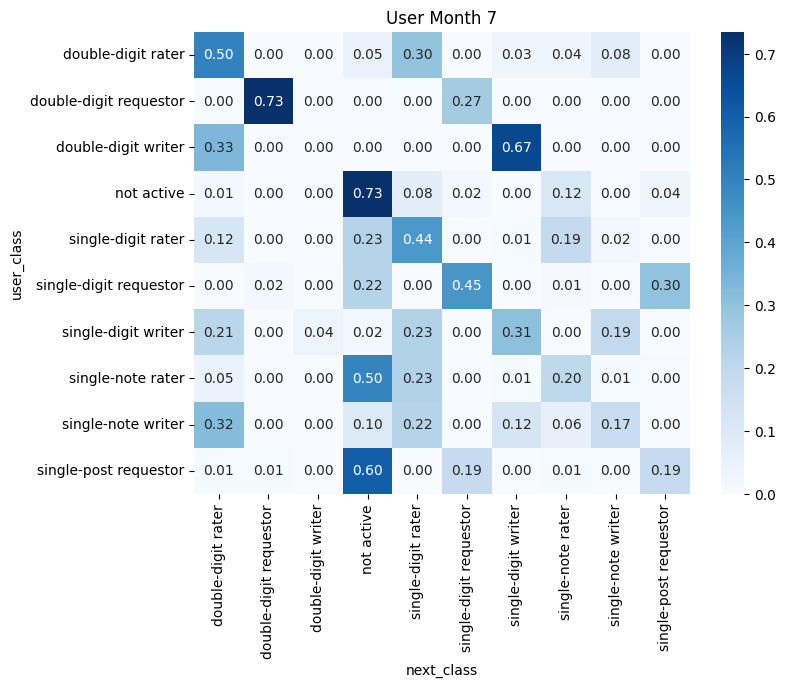

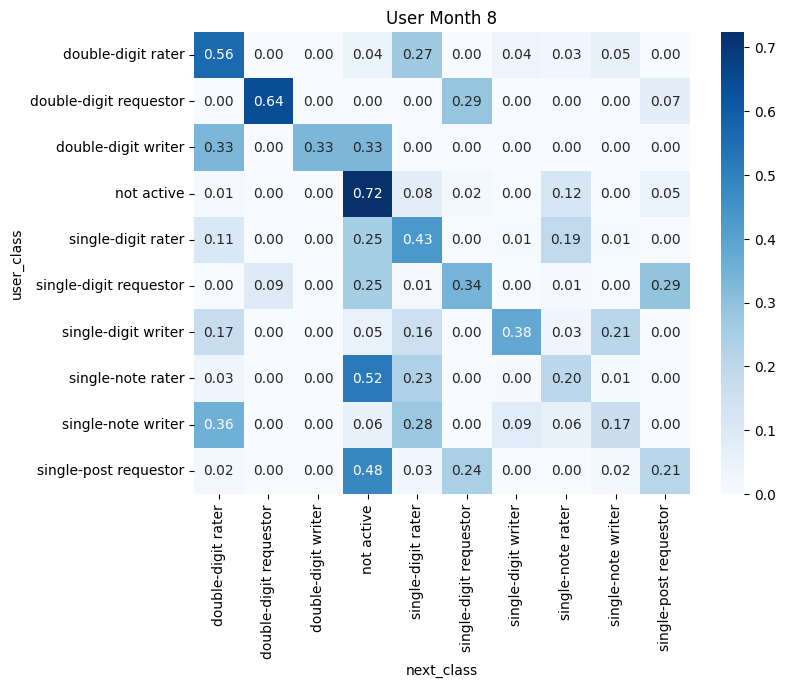

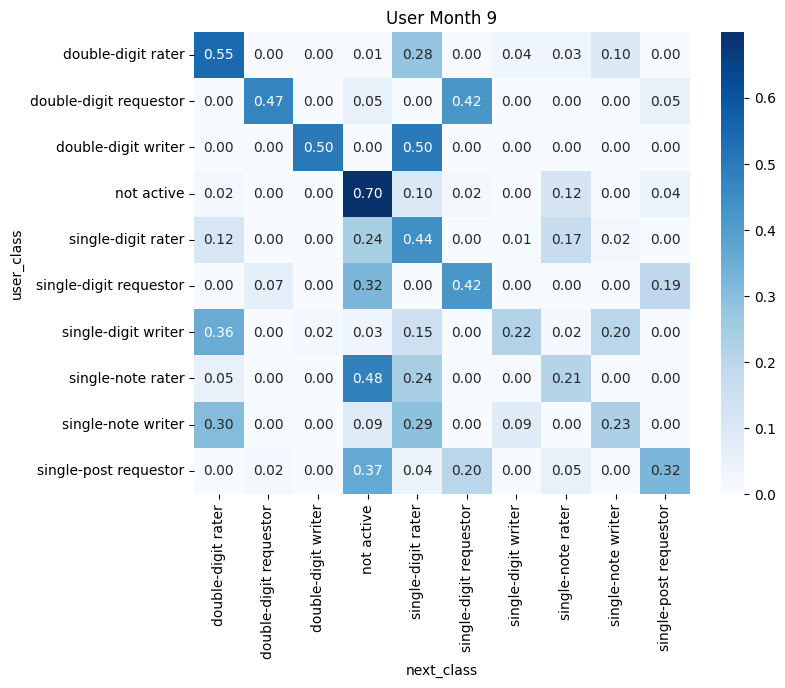

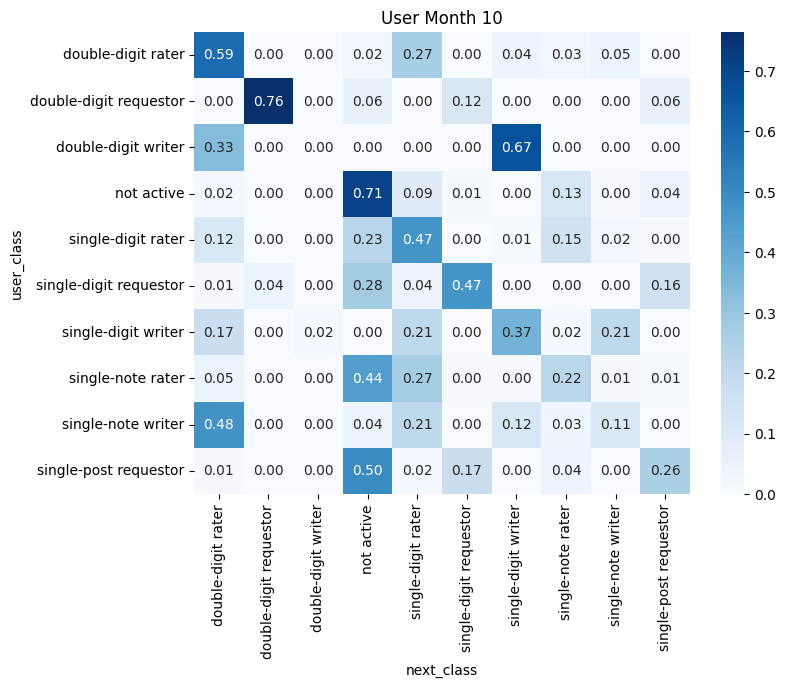

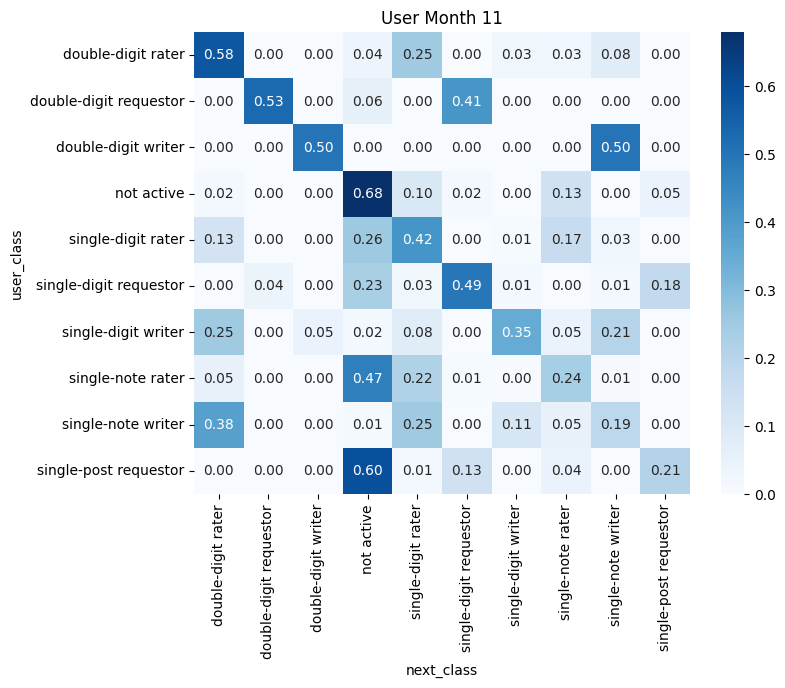

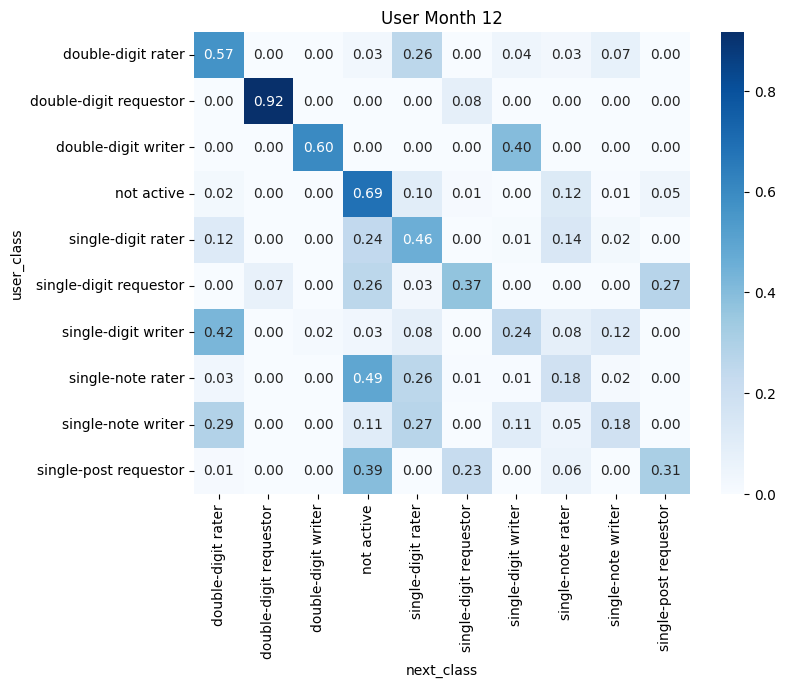

In [230]:
for m in range (1, 13):
    temp = transitions[transitions['userMonth'] == m]

    probs = pd.crosstab(temp['user_class'], temp['next_class'])
    probs = probs.div(probs.sum(axis=1), axis=0)

    plt.figure(figsize=(8,6))
    sns.heatmap(probs, annot=True, fmt=".2f", cmap="Blues")
    plt.title(f"User Month {m}")
    plt.show()